# Day 50 - Kernel PCA avec kernel sigmoid sur Breast Cancer Wisconsin

## Objectif
Appliquer **Kernel PCA** (kernel='sigmoid') sur le dataset Breast Cancer Wisconsin pour réduire la dimensionnalité de 30 features vers 2 composantes, puis classifier (malignant vs benign) et visualiser les résultats.



In [1]:
# Import des librairies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
# Chargement du dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')  # 0 = malignant, 1 = benign

print("Shape du dataset :", X.shape)
print("\nClasses :", np.bincount(y))
print("0 = Malignant (cancer) :", np.bincount(y)[0])
print("1 = Benign (non-cancer) :", np.bincount(y)[1])

X.head()

Shape du dataset : (569, 30)

Classes : [212 357]
0 = Malignant (cancer) : 212
1 = Benign (non-cancer) : 357


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


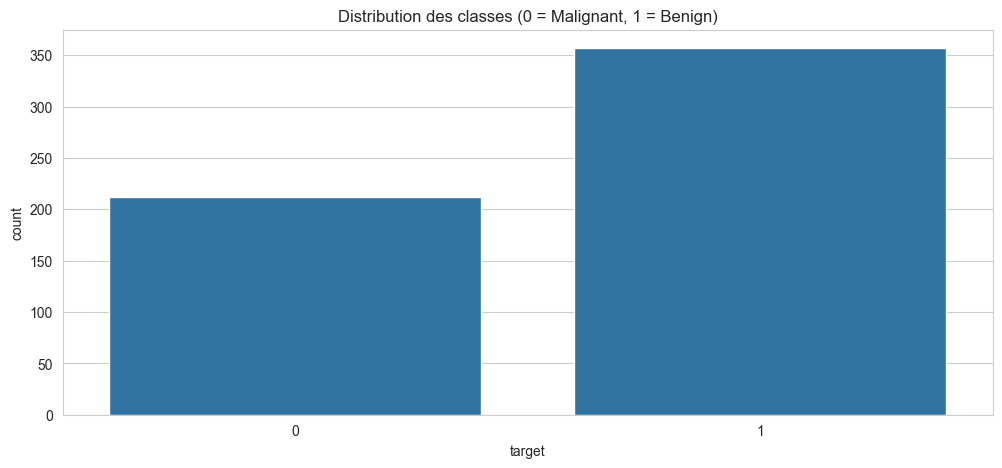

In [4]:
plt.figure()
sns.countplot(x=y)
plt.title('Distribution des classes (0 = Malignant, 1 = Benign)')
plt.show()

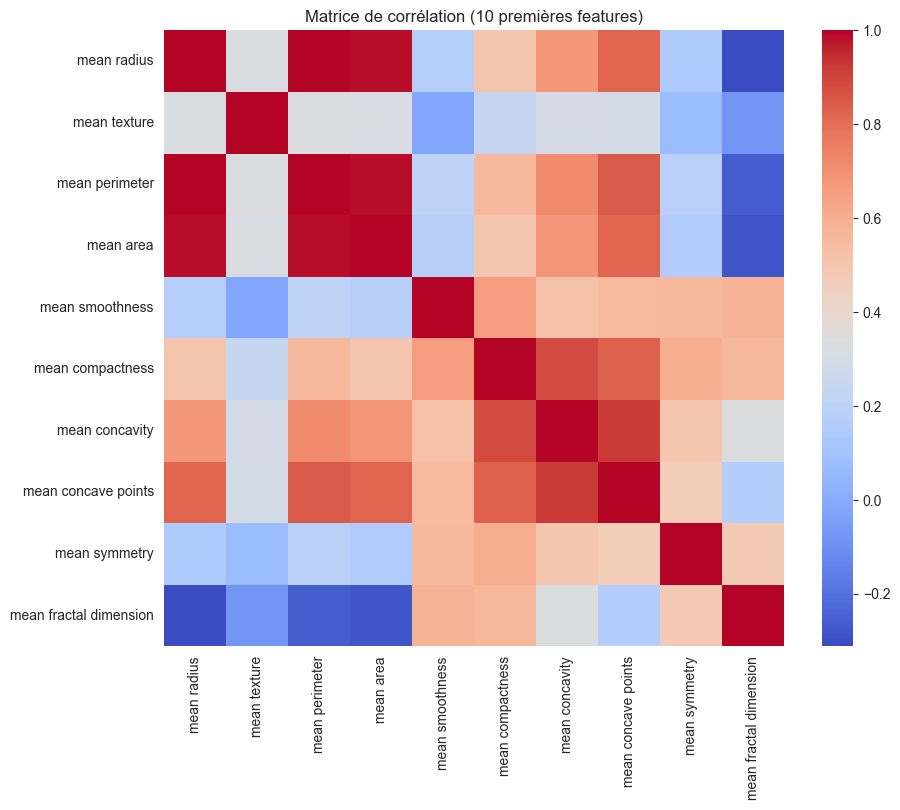

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(X.iloc[:, :10].corr(), annot=False, cmap='coolwarm')
plt.title('Matrice de corrélation (10 premières features)')
plt.show()

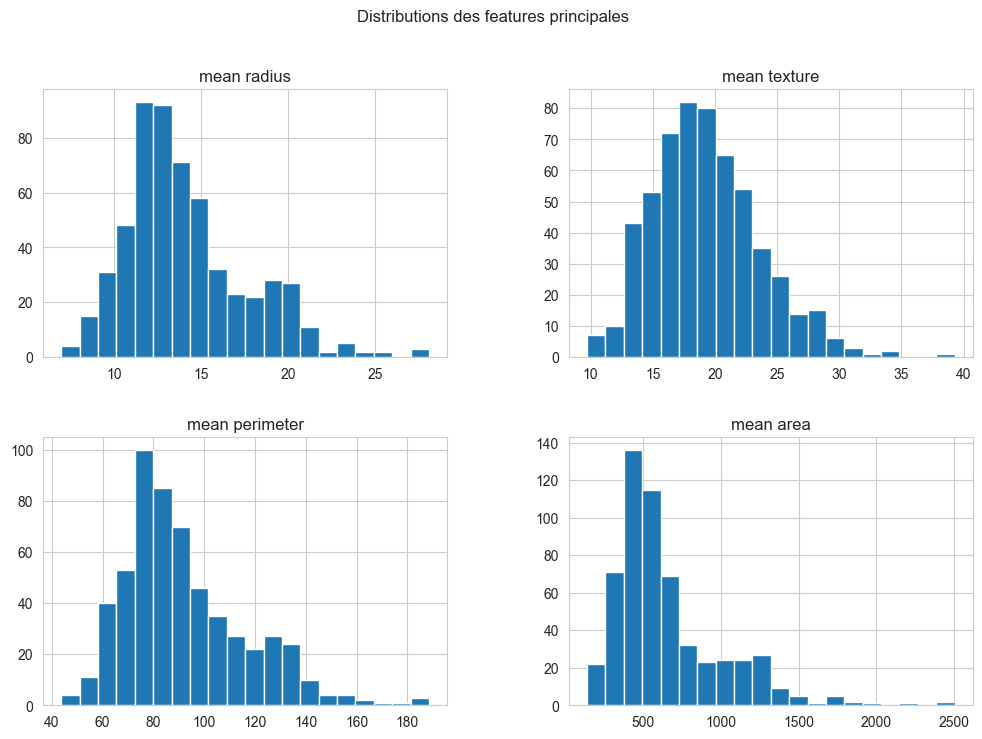

In [6]:
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
X[features_to_plot].hist(bins=20, figsize=(12, 8))
plt.suptitle('Distributions des features principales')
plt.show()

In [7]:
# Split en 3 jeux : train, validation, test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 0.25 de 80% = 20% du total -> validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print("Train shape :", X_train.shape)
print("Validation shape :", X_val.shape)
print("Test shape :", X_test.shape)

Train shape : (341, 30)
Validation shape : (114, 30)
Test shape : (114, 30)


In [8]:



gammas = [0.001, 0.01, 0.05, 0.1, 0.5]
accuracies = []

for g in gammas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('kpca', KernelPCA(n_components=2, kernel='sigmoid', gamma=g, coef0=1.0, random_state=42)),
        ('clf', LogisticRegression(random_state=42))
    ])
    pipe.fit(X_train, y_train)
    acc = accuracy_score(y_val, pipe.predict(X_val))
    accuracies.append(acc)
    print(f"gamma={g} → Accuracy = {acc:.4f}")

# Meilleur gamma
best_idx = np.argmax(accuracies)
print(f"\nMeilleur gamma : {gammas[best_idx]} avec accuracy {accuracies[best_idx]:.4f}")

gamma=0.001 → Accuracy = 0.7456
gamma=0.01 → Accuracy = 0.9298
gamma=0.05 → Accuracy = 0.9474
gamma=0.1 → Accuracy = 0.9474
gamma=0.5 → Accuracy = 0.9474

Meilleur gamma : 0.05 avec accuracy 0.9474


In [9]:
# Pipeline final : Standardisation + KernelPCA (sigmoid) + Régression Logistique
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kpca', KernelPCA(n_components=2,
                       kernel='sigmoid',
                       gamma=gammas[best_idx],
                       coef0=1.0,
                       random_state=42)),
    ('classifier', LogisticRegression(random_state=42))
])

# Entraînement sur train
pipeline.fit(X_train, y_train)

# Prédictions sur test (jamais vu pendant le tuning)
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

Accuracy (test) : 0.9473684210526315

Classification Report (test) :
               precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

ROC AUC (test) : 0.9871031746031746


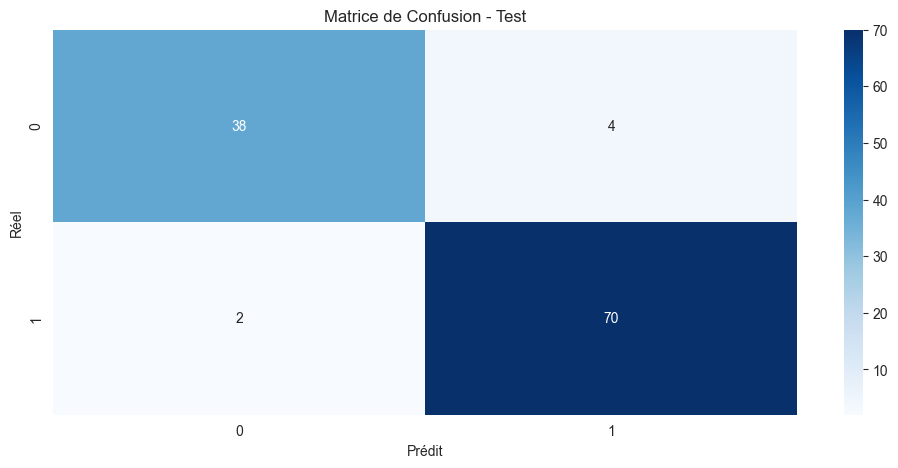

In [10]:
# Évaluation finale sur le jeu de test
print("Accuracy (test) :", accuracy_score(y_test, y_pred))
print("\nClassification Report (test) :\n", classification_report(y_test, y_pred))
print("ROC AUC (test) :", roc_auc_score(y_test, y_pred_proba))

# Matrice de confusion (test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion - Test')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

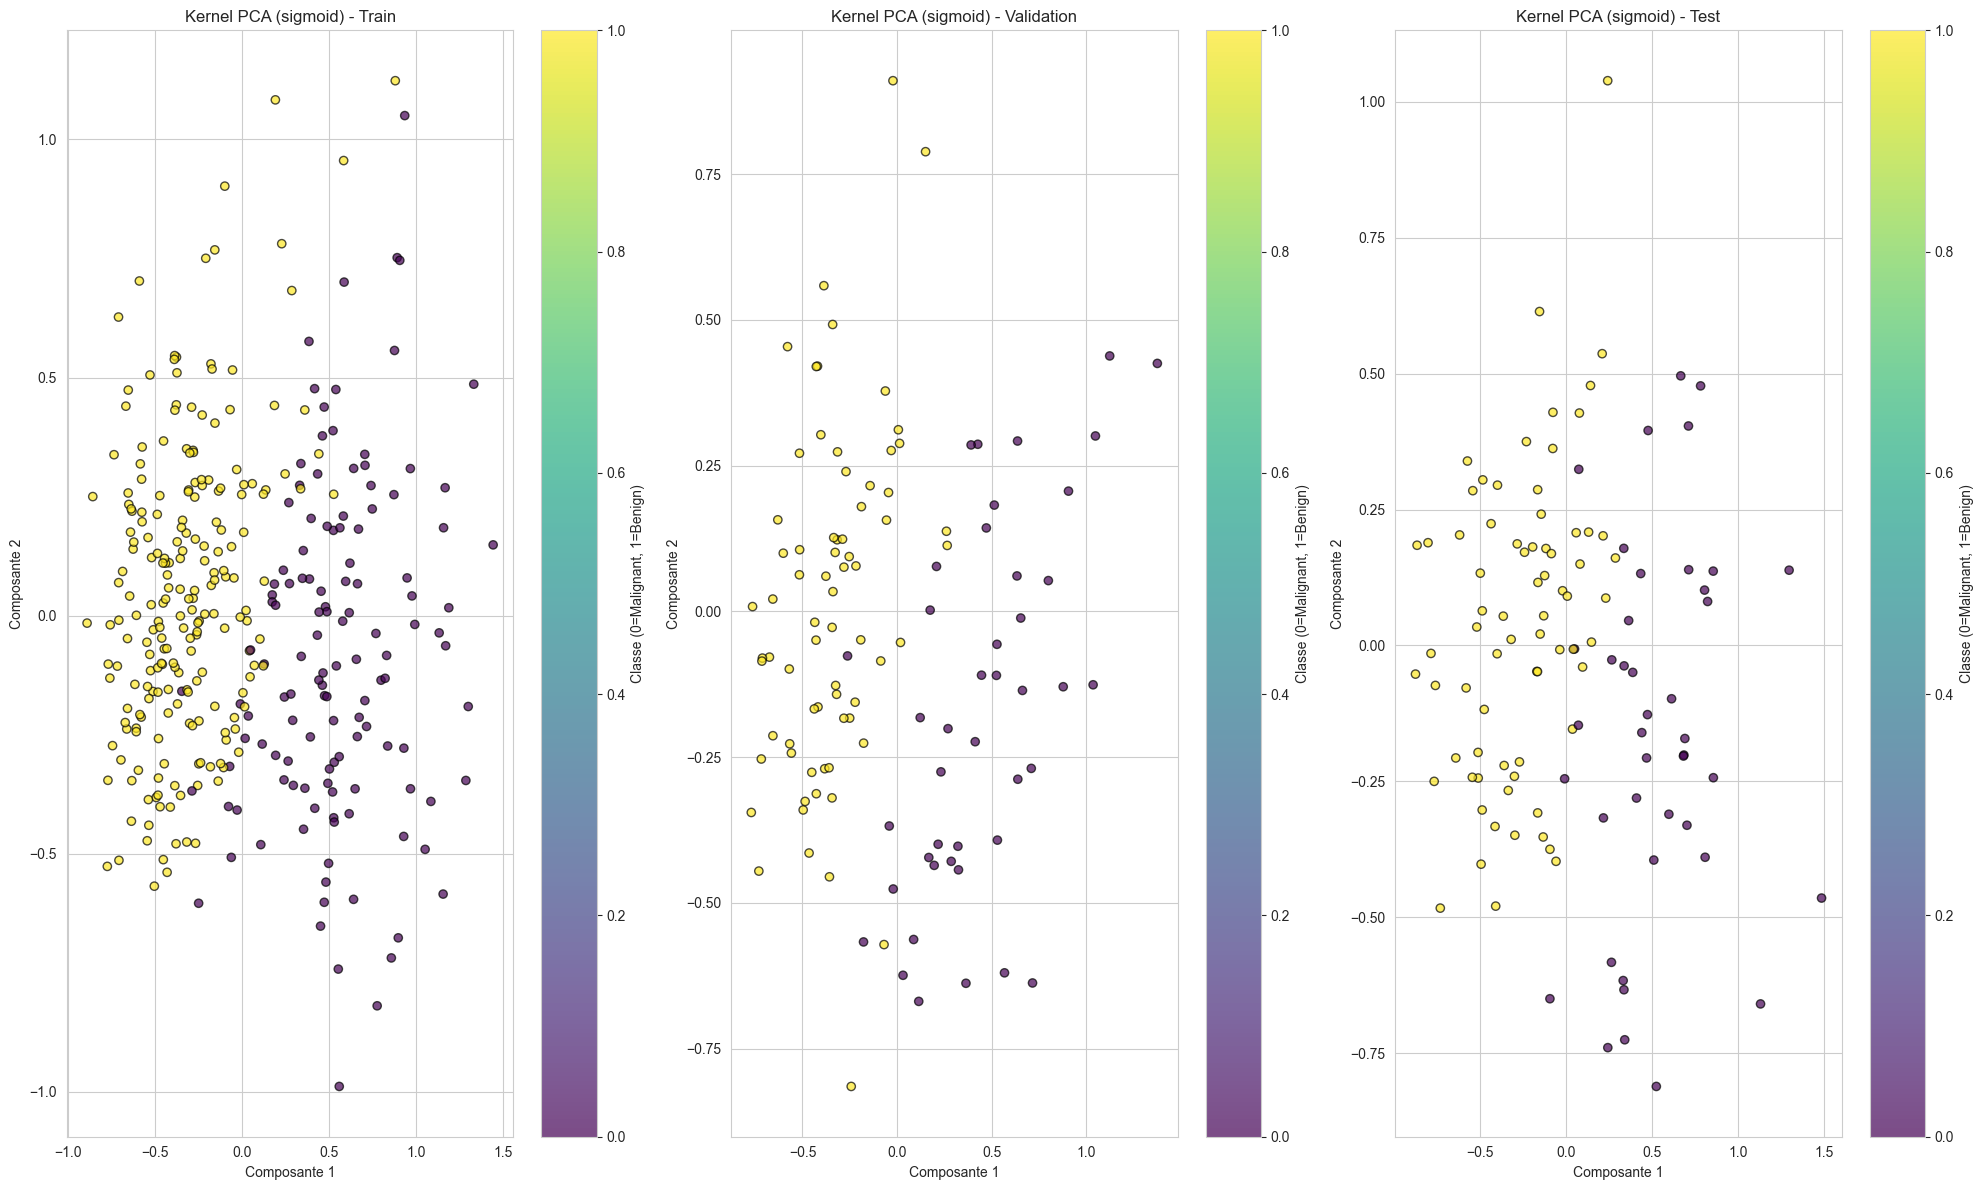

In [12]:
# Projection Kernel PCA avec le meilleur gamma
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

kpca = KernelPCA(
    n_components=2,
    kernel='sigmoid',
    gamma=gammas[best_idx],
    coef0=1.0,
    random_state=42
)
X_train_kpca = kpca.fit_transform(X_train_scaled)
X_val_kpca = kpca.transform(X_val_scaled)
X_test_kpca = kpca.transform(X_test_scaled)

# Visualisation 2D
plt.figure(figsize=(20, 12))

plt.subplot(1, 3, 1)
plt.scatter(X_train_kpca[:, 0], X_train_kpca[:, 1], c=y_train, cmap='viridis', edgecolor='k', alpha=0.7)
plt.title('Kernel PCA (sigmoid) - Train')
plt.xlabel('Composante 1')
plt.ylabel('Composante 2')
plt.colorbar(label='Classe (0=Malignant, 1=Benign)')

plt.subplot(1, 3, 2)
plt.scatter(X_val_kpca[:, 0], X_val_kpca[:, 1], c=y_val, cmap='viridis', edgecolor='k', alpha=0.7)
plt.title('Kernel PCA (sigmoid) - Validation')
plt.xlabel('Composante 1')
plt.ylabel('Composante 2')
plt.colorbar(label='Classe (0=Malignant, 1=Benign)')

plt.subplot(1, 3, 3)
plt.scatter(X_test_kpca[:, 0], X_test_kpca[:, 1], c=y_test, cmap='viridis', edgecolor='k', alpha=0.7)
plt.title('Kernel PCA (sigmoid) - Test')
plt.xlabel('Composante 1')
plt.ylabel('Composante 2')
plt.colorbar(label='Classe (0=Malignant, 1=Benign)')

plt.tight_layout()
plt.show()